# Chess Cheating Detection via TDA Mapper v2

Full pipeline:
1. Load the Kaggle chess cheating dataset
2. Parse PGNs and extract per-game behavioral features using Stockfish (no asyncio)
3. Apply the Mapper algorithm (kmapper)
4. Visualize and interpret the topological graph

**Requirements:**
```
pip install chess kmapper scikit-learn umap-learn pandas numpy matplotlib networkx
```
Stockfish binary: https://stockfishchess.org/download/

## Cell 1 — Imports

In [1]:
# Uncomment to install if needed:
# !pip install chess kmapper scikit-learn pandas numpy matplotlib networkx

import subprocess
import chess
import chess.pgn
import numpy as np
import pandas as pd
import io
import warnings
warnings.filterwarnings('ignore')

import kmapper as km
import networkx as nx
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

print('All imports successful.')

All imports successful.


## Cell 2 — Configuration

In [4]:
# ============================================================
# UPDATE THESE TWO PATHS BEFORE RUNNING
# ============================================================

# Path to your downloaded CSV from Kaggle
DATASET_PATH = "Games.csv"

# Path to Stockfish executable
# Windows: r"C:\stockfish\stockfish.exe"  or  r".\stockfish.exe"
# Mac/Linux: "/usr/local/bin/stockfish"
STOCKFISH_PATH = r".\stockfish.exe"  # <-- UPDATE THIS

# Stockfish depth (10-12 = good balance of speed vs accuracy)
ANALYSIS_DEPTH = 12

# Number of games to process (None = all games)
MAX_GAMES = 300

print(f"Config: depth={ANALYSIS_DEPTH}, max_games={MAX_GAMES}")

Config: depth=12, max_games=300


## Cell 3 — Load dataset & normalise column names

In [5]:
df = pd.read_csv(DATASET_PATH)
print("Shape:", df.shape)
print("Raw columns:", df.columns.tolist())

# Auto-map column names (case-insensitive)
col_map = {}
targets = {
    'game':        ['game', 'pgn', 'moves'],
    'elo_white':   ['elo white', 'elowhite', 'elo_white', 'white elo', 'white_elo'],
    'elo_black':   ['elo black', 'eloblack', 'elo_black', 'black elo', 'black_elo'],
    'cheat_white': ['liste cheat white', 'cheat_white', 'cheatwhite', 'liste_cheat_white'],
    'cheat_black': ['liste cheat black', 'cheat_black', 'cheatblack', 'liste_cheat_black'],
    'score':       ['score', 'result', 'outcome'],
}
for canonical, variants in targets.items():
    for col in df.columns:
        if col.strip().lower() in variants:
            col_map[col] = canonical
            break

df = df.rename(columns=col_map)
print("Mapped columns:", col_map)

required = ['game', 'elo_white', 'elo_black', 'cheat_white', 'cheat_black']
missing  = [c for c in required if c not in df.columns]
if missing:
    print(f"WARNING: Missing columns: {missing} — update targets dict above")
else:
    print("All required columns found.")

# Preview raw cheat values so we know what format they are
print("\nSample cheat_white value:")
print(repr(df['cheat_white'].iloc[0]))
print("Sample cheat_black value:")
print(repr(df['cheat_black'].iloc[0]))

Shape: (48932, 6)
Raw columns: ['Liste cheat white', 'Liste cheat black', 'Game', 'Elo White', 'Elo Black', 'Score']
Mapped columns: {'Game': 'game', 'Elo White': 'elo_white', 'Elo Black': 'elo_black', 'Liste cheat white': 'cheat_white', 'Liste cheat black': 'cheat_black', 'Score': 'score'}
All required columns found.

Sample cheat_white value:
1111101010111010100110000001001111
Sample cheat_black value:
111001000000001100100000000111000


## Cell 4 — Stockfish wrapper (no asyncio)

In [6]:
class StockfishDirect:
    """
    Minimal Stockfish wrapper over raw stdin/stdout.
    No asyncio — works reliably on Windows + Jupyter.
    """
    def __init__(self, path, depth=12):
        self.depth = depth
        self.proc  = subprocess.Popen(
            path,
            stdin=subprocess.PIPE,
            stdout=subprocess.PIPE,
            stderr=subprocess.DEVNULL,
            text=True,
            bufsize=1
        )
        self._send("uci")
        self._wait_for("uciok")
        self._send("isready")
        self._wait_for("readyok")
        print("Stockfish ready.")

    def _send(self, cmd):
        self.proc.stdin.write(cmd + "\n")
        self.proc.stdin.flush()

    def _wait_for(self, token):
        while True:
            line = self.proc.stdout.readline()
            if token in line:
                return line

    def analyse(self, fen, multipv=3):
        """
        Returns dict: {rank -> {score_cp, move}} where score_cp is
        centipawns from White's perspective, capped at +/-10000 for mates.
        """
        self._send("ucinewgame")
        self._send(f"position fen {fen}")
        self._send(f"go depth {self.depth} multipv {multipv}")

        results = {}
        while True:
            line = self.proc.stdout.readline().strip()
            if line.startswith("bestmove"):
                break

            if " pv " not in line:
                continue

            parts = line.split()
            try:
                multipv_id = int(parts[parts.index("multipv") + 1]) if "multipv" in parts else 1
                pv_idx     = parts.index("pv")
                best_move  = parts[pv_idx + 1]

                if "score cp" in line:
                    cp_idx   = parts.index("cp")
                    score_cp = int(parts[cp_idx + 1])
                    # Clamp extreme values (shouldn't be >3000 in normal play)
                    score_cp = max(-10000, min(10000, score_cp))

                elif "score mate" in line:
                    mate_idx = parts.index("mate")
                    mate_in  = int(parts[mate_idx + 1])
                    # Use 10000cp for mate — large but not astronomically so
                    score_cp = 10000 if mate_in > 0 else -10000
                else:
                    continue

                results[multipv_id] = {"score_cp": score_cp, "move": best_move}

            except (ValueError, IndexError):
                continue

        return results

    def close(self):
        try:
            self._send("quit")
            self.proc.wait(timeout=3)
        except Exception:
            self.proc.kill()

    def __enter__(self):  return self
    def __exit__(self, *a): self.close()


# Quick test — will raise immediately if path is wrong
try:
    with StockfishDirect(STOCKFISH_PATH, depth=5) as sf:
        r = sf.analyse("rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1")
        print("Test analysis result:", r)
except Exception as e:
    print(f"ERROR: Could not start Stockfish: {e}")
    print("Check STOCKFISH_PATH in Cell 2.")

Stockfish ready.
Test analysis result: {1: {'score_cp': 29, 'move': 'e2e4'}}


## Cell 5 — Feature extraction functions

In [7]:
def max_streak(arr):
    """Longest consecutive run of 1s."""
    best, cur = 0, 0
    for x in arr:
        cur = cur + 1 if x == 1 else 0
        best = max(best, cur)
    return best


def parse_cheat_label(val):
    """
    Handles all observed formats in this dataset:
      - Plain 0 or 1 (integer)
      - '0' or '1' (string)
      - Long binary string like '11111010101110...' — majority vote
      - NaN -> 0
    """
    if pd.isna(val):
        return 0
    s = str(val).strip()
    if s in ("0", "1"):
        return int(s)
    # Long binary string
    bits = [c for c in s if c in ("0", "1")]
    if bits:
        return int(sum(int(b) for b in bits) / len(bits) > 0.5)
    return 0


def extract_game_features(pgn_string, engine):
    """
    Parse a PGN and return a dict of behavioral features.
    Returns None if the game is unparseable or too short.
    """
    try:
        pgn  = io.StringIO(str(pgn_string))
        game = chess.pgn.read_game(pgn)
        if game is None:
            return None
    except Exception:
        return None

    board = game.board()
    moves = list(game.mainline_moves())
    if len(moves) < 10:
        return None

    centipawn_losses = []
    top1_agreements  = []
    top3_agreements  = []
    critical_accs    = []
    prev_score       = None

    for move in moves:
        try:
            fen     = board.fen()
            results = engine.analyse(fen, multipv=3)
            if not results or 1 not in results:
                board.push(move)
                continue

            top_moves = [results[k]["move"] for k in sorted(results.keys())]
            top_score = results[1]["score_cp"]
            move_uci  = move.uci()

            top1_agreements.append(1 if move_uci == top_moves[0] else 0)
            top3_agreements.append(1 if move_uci in top_moves else 0)

            board.push(move)

            after_results = engine.analyse(board.fen(), multipv=1)
            if not after_results or 1 not in after_results:
                continue
            after_score = after_results[1]["score_cp"]

            # CPL from the moving player's perspective
            if board.turn == chess.BLACK:   # white just moved
                loss = top_score - after_score
            else:                           # black just moved
                loss = after_score - top_score

            # Cap: mates inflate CPL; anything over 1000cp is a tactical shot
            loss = max(0, min(loss, 1000))
            centipawn_losses.append(loss)

            # Critical move: large swing from previous position
            if prev_score is not None and abs(top_score - prev_score) > 100:
                critical_accs.append(1 if move_uci == top_moves[0] else 0)

            prev_score = after_score

        except Exception:
            try:
                board.push(move)
            except Exception:
                pass
            continue

    if len(centipawn_losses) < 5:
        return None

    mean_cpl = np.mean(centipawn_losses)

    # Sanity check: real chess mean CPL is almost never above 400
    if mean_cpl > 400:
        return None

    return {
        "mean_cpl":               mean_cpl,
        "std_cpl":                np.std(centipawn_losses),
        "engine_agreement_rate":  np.mean(top1_agreements),
        "top3_agreement_rate":    np.mean(top3_agreements),
        "top1_streak_max":        max_streak(top1_agreements),
        "critical_move_accuracy": np.mean(critical_accs) if critical_accs else np.nan,
        "n_moves":                len(centipawn_losses),
    }


print("Feature functions defined.")

Feature functions defined.


## Cell 6 — Run Stockfish over all games

⚠️ This is the slow step (~5–15 sec/game at depth 12).
With MAX_GAMES=300 expect 30–60 minutes.
Reduce ANALYSIS_DEPTH to 8 or MAX_GAMES to 100 for a quick test.

In [8]:
sample = df.iloc[:MAX_GAMES] if MAX_GAMES else df
rows   = []
failed = 0

with StockfishDirect(STOCKFISH_PATH, depth=ANALYSIS_DEPTH) as engine:
    for i, (_, row) in enumerate(sample.iterrows()):

        feats = extract_game_features(row["game"], engine)
        if feats is None:
            failed += 1
            continue

        feats["elo_white"]    = pd.to_numeric(row.get("elo_white"),  errors='coerce')
        feats["elo_black"]    = pd.to_numeric(row.get("elo_black"),  errors='coerce')
        feats["cheat_white"]  = parse_cheat_label(row.get("cheat_white"))
        feats["cheat_black"]  = parse_cheat_label(row.get("cheat_black"))
        feats["either_cheat"] = int(feats["cheat_white"] or feats["cheat_black"])
        rows.append(feats)

        if (i + 1) % 25 == 0:
            cheat_so_far = sum(r['either_cheat'] for r in rows)
            print(f"  {i+1}/{len(sample)} processed | "
                  f"{len(rows)} extracted | "
                  f"{failed} failed | "
                  f"cheat so far: {cheat_so_far}/{len(rows)} "
                  f"({100*cheat_so_far/max(1,len(rows)):.1f}%)")

feat_df = pd.DataFrame(rows)
print(f"\nDone. {len(feat_df)} games extracted, {failed} skipped.")
print(f"Cheat rate: {feat_df['either_cheat'].mean()*100:.1f}%")
feat_df.head()

Stockfish ready.
  25/300 processed | 16 extracted | 9 failed | cheat so far: 13/16 (81.2%)
  50/300 processed | 30 extracted | 20 failed | cheat so far: 23/30 (76.7%)
  75/300 processed | 48 extracted | 27 failed | cheat so far: 34/48 (70.8%)
  100/300 processed | 62 extracted | 38 failed | cheat so far: 46/62 (74.2%)
  125/300 processed | 80 extracted | 45 failed | cheat so far: 60/80 (75.0%)
  175/300 processed | 111 extracted | 64 failed | cheat so far: 84/111 (75.7%)
  250/300 processed | 155 extracted | 95 failed | cheat so far: 115/155 (74.2%)

Done. 179 games extracted, 121 skipped.
Cheat rate: 75.4%


,mean_cpl,std_cpl,engine_agreement_rate,top3_agreement_rate,top1_streak_max,critical_move_accuracy,n_moves,elo_white,elo_black,cheat_white,cheat_black,either_cheat
0,7.092784,24.785298,0.612245,0.612245,9,NaN,97,1001,-1,1,1,1
1,318.298387,438.423201,0.552000,0.552000,6,NaN,124,1001,-1,1,1,1
2,373.144737,414.968696,0.558442,0.558442,6,NaN,76,1002,-1,1,1,1
3,305.794118,451.794463,0.503650,0.503650,12,NaN,136,1002,-1,1,0,1
4,67.631579,69.889796,0.448276,0.448276,5,NaN,57,1003,-1,0,1,1


## Cell 7 — Save extracted features (run once, reload later)

In [9]:
feat_df.to_csv("chess_features_extracted.csv", index=False)
print("Saved to chess_features_extracted.csv")
print("Next time skip Cells 4-6 and run: feat_df = pd.read_csv('chess_features_extracted.csv')")

Saved to chess_features_extracted.csv
Next time skip Cells 4-6 and run: feat_df = pd.read_csv('chess_features_extracted.csv')


## Cell 7b — Reload from saved CSV (skip Stockfish on subsequent runs)

In [10]:
# Uncomment this block and run instead of Cells 4-6 on subsequent runs:
# feat_df = pd.read_csv("chess_features_extracted.csv")
# print(f"Loaded {len(feat_df)} games.")
# print(f"Cheat rate: {feat_df['either_cheat'].mean()*100:.1f}%")
# feat_df.head()

## Cell 8 — Feature inspection

In [11]:
print(feat_df.describe().round(3))
print(f"\nCheat distribution:")
print(feat_df['either_cheat'].value_counts())
print(f"Cheat rate: {feat_df['either_cheat'].mean()*100:.1f}%")

       mean_cpl  std_cpl  engine_agreement_rate  top3_agreement_rate  \
count   179.000  179.000                179.000              179.000   
mean    110.785  153.560                  0.466                0.466   
std     116.059  133.700                  0.079                0.079   
min       0.090    0.843                  0.125                0.125   
25%      21.023   43.582                  0.422                0.422   
50%      65.132   99.397                  0.467                0.467   
75%     172.825  257.561                  0.510                0.510   
max     397.574  454.022                  0.726                0.726   

       top1_streak_max  critical_move_accuracy  n_moves  elo_white  elo_black  \
count          179.000                     0.0  179.000    179.000    179.000   
mean             5.598                     NaN   85.257   1080.380    370.017   
std              2.124                     NaN   39.567    217.245    589.427   
min              1.000     

## Cell 9 — Distribution plots: clean vs cheating

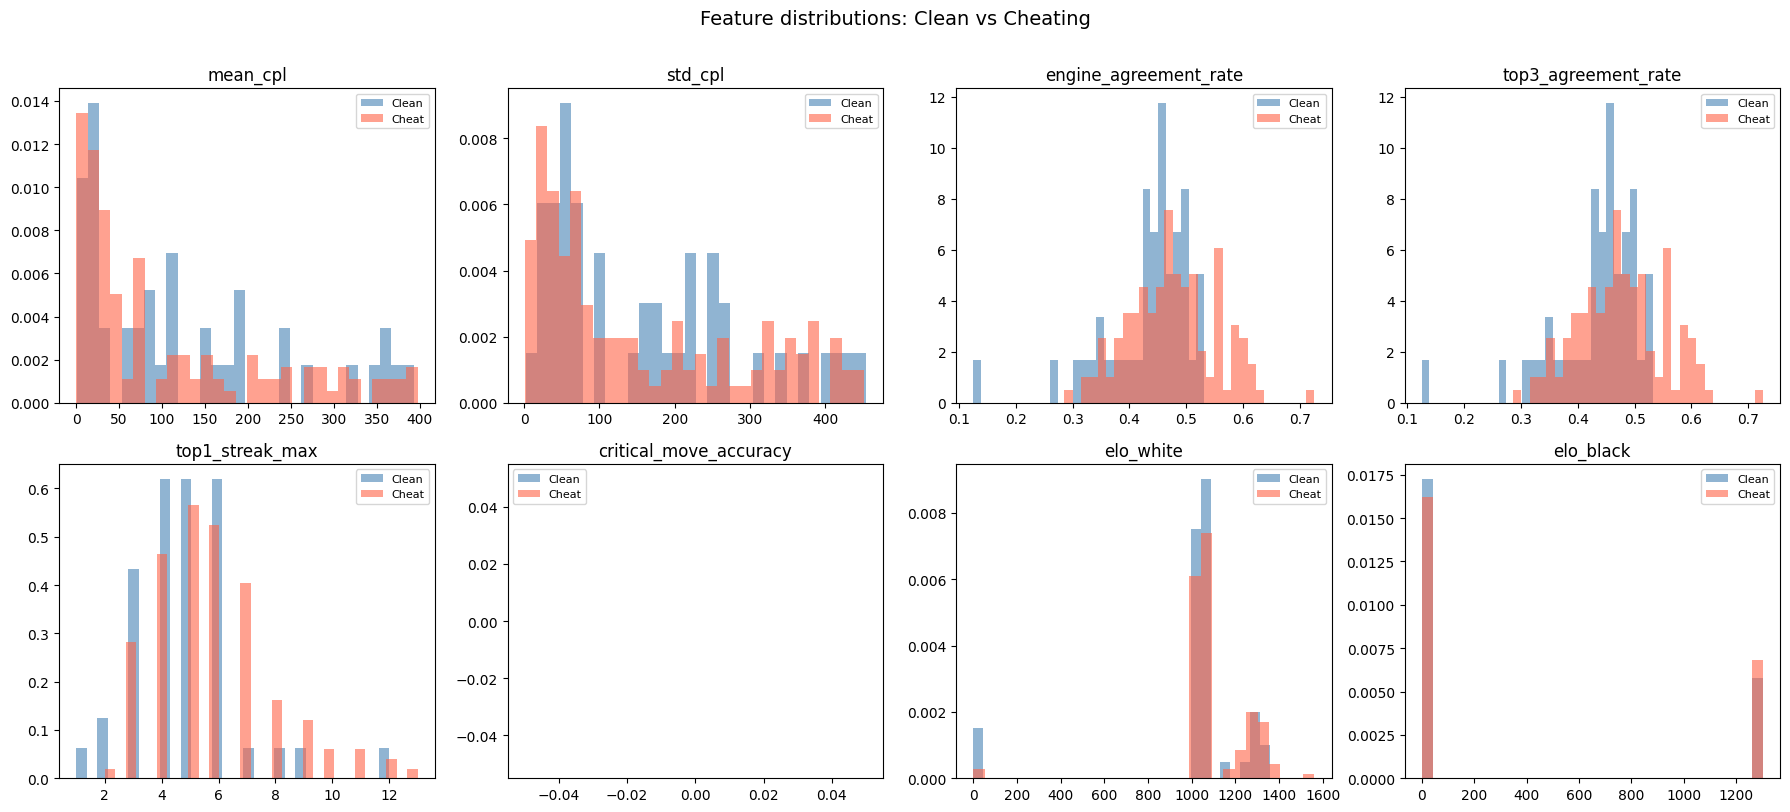


Correlation with cheat label:
mean_cpl                 -0.066
std_cpl                  -0.026
elo_black                 0.044
elo_white                 0.166
top1_streak_max           0.210
engine_agreement_rate     0.236
top3_agreement_rate       0.236
critical_move_accuracy      NaN
Name: either_cheat, dtype: float64


In [12]:
feature_cols = ["mean_cpl", "std_cpl", "engine_agreement_rate",
                "top3_agreement_rate", "top1_streak_max",
                "critical_move_accuracy", "elo_white", "elo_black"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    clean = feat_df[feat_df["either_cheat"] == 0][col].dropna()
    cheat = feat_df[feat_df["either_cheat"] == 1][col].dropna()
    axes[i].hist(clean, bins=30, alpha=0.6, color='steelblue', label='Clean', density=True)
    axes[i].hist(cheat, bins=30, alpha=0.6, color='tomato',    label='Cheat', density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.suptitle('Feature distributions: Clean vs Cheating', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Correlation with cheat label
corr = feat_df[feature_cols + ['either_cheat']].corr()['either_cheat'].drop('either_cheat').sort_values()
print("\nCorrelation with cheat label:")
print(corr.round(3))

## Cell 10 — Prepare feature matrix for Mapper

In [13]:
feature_cols = ["mean_cpl", "std_cpl", "engine_agreement_rate",
                "top3_agreement_rate", "top1_streak_max",
                "critical_move_accuracy", "elo_white", "elo_black"]

# Fill NaN in critical_move_accuracy with column median before dropping
feat_df["critical_move_accuracy"] = feat_df["critical_move_accuracy"].fillna(
    feat_df["critical_move_accuracy"].median()
)

feat_df_clean = feat_df.dropna(subset=feature_cols).reset_index(drop=True)
print(f"Rows after dropping NaN: {len(feat_df_clean)}")

X_raw = feat_df_clean[feature_cols].values
y     = feat_df_clean["either_cheat"].values.astype(int)

scaler = StandardScaler()
X      = scaler.fit_transform(X_raw)

print(f"Feature matrix: {X.shape}")
print(f"Cheat rate: {y.mean()*100:.1f}%")

Rows after dropping NaN: 0


ValueError: Found array with 0 sample(s) (shape=(0, 8)) while a minimum of 1 is required by StandardScaler.

## Cell 11 — Apply Mapper

Two lens options:
- **Lens A**: engine agreement rate — most interpretable for this domain
- **Lens B**: PCA 2D — captures combined variance across all features

Switch `lens = lens_A` to `lens = lens_B` to compare.

In [ ]:
mapper = km.KeplerMapper(verbose=1)

# Lens A: engine agreement rate (single feature, most interpretable)
agreement_idx = feature_cols.index("engine_agreement_rate")
lens_A        = X[:, agreement_idx].reshape(-1, 1)

# Lens B: PCA 2D projection
lens_B     = PCA(n_components=2).fit_transform(X)

# --- Choose lens here ---
lens      = lens_A
lens_name = "Engine Agreement Rate"

graph = mapper.map(
    lens,
    X,
    clusterer=DBSCAN(eps=0.6, min_samples=3),
    cover=km.Cover(n_cubes=12, perc_overlap=0.4)
)

n_nodes = len(graph["nodes"])
n_edges = sum(len(v) for v in graph["links"].values())
print(f"\nMapper graph: {n_nodes} nodes, {n_edges} edges")

## Cell 12 — Interactive HTML visualisation

In [ ]:
html_path = "chess_cheating_mapper.html"
mapper.visualize(
    graph,
    path_html=html_path,
    color_values=y,
    color_function_name="Cheat Label (0=clean, 1=cheat)",
    title=f"Chess Cheating — Mapper (lens: {lens_name})"
)
print(f"Saved to {html_path} — open in browser for interactive view.")

## Cell 13 — Static matplotlib visualisation

In [ ]:
# Per-node cheat rate and size
node_cheat_rate = {}
node_size       = {}
for node, indices in graph["nodes"].items():
    node_cheat_rate[node] = float(np.mean(y[indices]))
    node_size[node]       = len(indices)

# Build networkx graph
G = nx.Graph()
for node in graph["nodes"]:
    G.add_node(node)
for node, neighbors in graph["links"].items():
    for nb in neighbors:
        G.add_edge(node, nb)

node_list = list(G.nodes())
colors    = [node_cheat_rate[n] for n in node_list]
sizes     = [max(80, node_size[n] * 25) for n in node_list]

fig, ax = plt.subplots(figsize=(14, 10))
pos     = nx.spring_layout(G, seed=42, k=0.9)

drawn = nx.draw_networkx_nodes(
    G, pos, node_color=colors, node_size=sizes,
    cmap=plt.cm.RdYlBu_r, vmin=0, vmax=1, ax=ax
)
nx.draw_networkx_edges(G, pos, alpha=0.25, ax=ax)

plt.colorbar(drawn, ax=ax, label='Cheat rate per node')
ax.set_title(f'Mapper Graph — Chess Cheating (lens: {lens_name})', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

## Cell 14 — Topological structure analysis

In [ ]:
degrees = dict(G.degree())

# Connected components
components = list(nx.connected_components(G))
print(f"Connected components: {len(components)}")
for i, comp in enumerate(sorted(components, key=len, reverse=True)[:5]):
    cheat_rates = [node_cheat_rate[n] for n in comp]
    total_games = sum(node_size[n] for n in comp)
    print(f"  Component {i+1}: {len(comp)} nodes | {total_games} games | "
          f"avg cheat rate={np.mean(cheat_rates):.2f}")

print()

# Cycles — H1 topological features
cycles = nx.cycle_basis(G)
print(f"Cycles (H1 features): {len(cycles)}")
for i, cycle in enumerate(cycles[:5]):
    cheat_rates = [node_cheat_rate[n] for n in cycle]
    print(f"  Cycle {i+1}: length={len(cycle)} | "
          f"cheat rate min={min(cheat_rates):.2f} "
          f"mean={np.mean(cheat_rates):.2f} "
          f"max={max(cheat_rates):.2f}")

print()

# High-degree hub nodes
print("Top hub nodes (highest degree):")
for n, d in sorted(degrees.items(), key=lambda x: -x[1])[:5]:
    print(f"  {n}: degree={d} | cheat_rate={node_cheat_rate[n]:.2f} | size={node_size[n]}")

print()

# Isolated high-cheat nodes — strongest anomaly signal
isolated_cheat = [n for n in G.nodes()
                  if node_cheat_rate[n] > 0.7 and degrees[n] <= 1]
print(f"Isolated high-cheat nodes (>70% cheat, degree ≤1): {len(isolated_cheat)}")
for n in isolated_cheat:
    print(f"  {n}: cheat_rate={node_cheat_rate[n]:.2f} | size={node_size[n]}")

## Cell 15 — Feature profiles: high-cheat vs clean nodes

In [ ]:
hc_indices = []
cl_indices = []

for node, indices in graph["nodes"].items():
    if node_cheat_rate[node] > 0.6:
        hc_indices.extend(indices)
    elif node_cheat_rate[node] < 0.1:
        cl_indices.extend(indices)

hc_indices = list(set(hc_indices))
cl_indices = list(set(cl_indices))

print(f"Games in high-cheat nodes (>60%): {len(hc_indices)}")
print(f"Games in clean nodes (<10%):      {len(cl_indices)}")

if hc_indices and cl_indices:
    hc_df = feat_df_clean.iloc[hc_indices][feature_cols]
    cl_df = feat_df_clean.iloc[cl_indices][feature_cols]

    comparison = pd.DataFrame({
        "Clean (mean)": cl_df.mean(),
        "Cheat (mean)": hc_df.mean(),
        "Delta":        hc_df.mean() - cl_df.mean()
    }).round(3)
    print("\nFeature comparison:")
    print(comparison)

    fig, ax = plt.subplots(figsize=(11, 5))
    x = np.arange(len(feature_cols))
    w = 0.35
    ax.bar(x - w/2, cl_df.mean(), w, label='Clean nodes', color='steelblue', alpha=0.8)
    ax.bar(x + w/2, hc_df.mean(), w, label='High-cheat nodes', color='tomato', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(feature_cols, rotation=30, ha='right')
    ax.set_title('Feature profiles: Clean vs High-cheat Mapper nodes')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Not enough nodes in one category — try adjusting Cover parameters in Cell 11.")

## Interpretation guide

| Pattern in graph | Meaning |
|---|---|
| Red cluster disconnected from main body | Cheating is topologically distinct — not just extreme normal play |
| Red tendril branching off | Cheaters as outliers on a behavioral spectrum |
| Loop spanning red + blue nodes | Two cheating strategies both converging at high accuracy |
| Red only at one end of a line | Cheating is a scalar extreme — weaker TDA signal |
| Graph too fragmented | Increase `perc_overlap` (0.5–0.6) or reduce `n_cubes` |

**Tuning tips:**
- Try `lens = lens_B` (PCA) in Cell 11 if the agreement-rate lens gives a boring linear structure
- Try `UMAP(n_components=2).fit_transform(X)` as a lens for non-linear structure
- Increase `n_cubes` to 15–20 for finer resolution
- Adjust `eps` in DBSCAN if nodes are too large or too small